In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/finclub-open-project-26/sandbox_solution.csv
/kaggle/input/competitions/finclub-open-project-26/submission-converter.ipynb
/kaggle/input/competitions/finclub-open-project-26/dataset.csv


# Implied Volatility Surface Reconstruction

This notebook builds a reproducible pipeline for predicting missing implied volatility (IV) values in the NIFTY options surface.

The key idea is to use the natural smoothness of IV across strikes at a fixed timestamp, while keeping the time-based component causal. For every timestamp, call and put smiles are fitted separately across log-moneyness. A small past-only residual adjustment is then added to correct persistent per-contract bias without using future information.

The notebook produces:

- `filled_dataset.csv`
- `submission.csv`

The final `submission.csv` follows the required Kaggle format: `id,value`.

## 1. Imports and Configuration

This section imports the required libraries and defines the file paths. The model is deterministic, so rerunning the notebook should reproduce the same submission file.

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 7
np.random.seed(SEED)

# ----------------------------
# Paths
# ----------------------------
DATA_PATH = "/kaggle/input/competitions/finclub-open-project-26/dataset.csv"
OUTPUT_DIR = "/kaggle/working"

FILLED_DATASET_PATH = os.path.join(OUTPUT_DIR, "filled_dataset.csv")
SUBMISSION_PATH = os.path.join(OUTPUT_DIR, "submission.csv")

ID_SEPARATOR = "||"

# Volatility should remain positive.
MIN_IV = 1e-3

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 2. Load Data and Decode Option Structure

Each option column contains the expiry, strike, and option type. The strike is extracted from the five digits immediately before the `CE` or `PE` suffix.

The data is converted into matrix form so the implied volatility surface can be modelled efficiently.

In [3]:
raw_df = pd.read_csv(DATA_PATH)

meta_cols = ["datetime", "underlying_price"]
option_cols = [col for col in raw_df.columns if col not in meta_cols]

# Extract strike and option type from column names.
strikes = np.array([
    int(re.search(r"(\d{5})(?=CE$|PE$)", col).group(1))
    for col in option_cols
], dtype=float)

option_type = np.array([col[-2:] for col in option_cols])

call_idx = np.where(option_type == "CE")[0]
put_idx = np.where(option_type == "PE")[0]

timestamps = pd.to_datetime(raw_df["datetime"], format="%d-%m-%Y %H:%M")
time_order = np.argsort(timestamps.values)

assert np.all(time_order == np.arange(len(raw_df))), "Rows are not sorted chronologically."

spot = raw_df["underlying_price"].to_numpy(float)
iv_matrix = raw_df[option_cols].to_numpy(float)

n_rows, n_options = iv_matrix.shape

# Log-moneyness is a natural coordinate for volatility smiles.
log_moneyness = np.log(strikes[None, :] / spot[:, None])

print(f"Dataset shape: {raw_df.shape}")
print(f"IV matrix shape: {iv_matrix.shape}")
print(f"Call columns: {len(call_idx)}")
print(f"Put columns : {len(put_idx)}")
print(f"Missing IV cells: {np.isnan(iv_matrix).sum()}")

raw_df.head()

Dataset shape: (975, 30)
IV matrix shape: (975, 28)
Call columns: 14
Put columns : 14
Missing IV cells: 5460


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,0.09864,0.09511,0.09304,0.09123,NaN,0.08843,0.18174,NaN,0.17206,0.16502,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,0.09896,NaN,0.09412,0.09136,0.09014,0.08885,0.18193,NaN,0.17226,0.16522,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


## 3. Exploratory Checks

The goal here is to understand the missingness pattern and the scale of IV values. This helps justify why interpolation and local smile fitting are reasonable choices.

In [4]:
missing_mask = np.isnan(iv_matrix)

print(f"Missing cells: {missing_mask.sum():,} / {iv_matrix.size:,} ({missing_mask.mean():.2%})")
print(f"Average missing per timestamp: {missing_mask.sum(axis=1).mean():.2f}")
print(f"Maximum missing in one timestamp: {missing_mask.sum(axis=1).max()}")

dates = timestamps.dt.date.astype(str).to_numpy()
unique_dates = pd.unique(dates)

print("\nPer-day observed IV summary:")
print(f"{'Date':<12} {'Median':>10} {'P95':>10} {'Max':>10}")

for d in unique_dates:
    vals = iv_matrix[dates == d]
    vals = vals[~np.isnan(vals)]
    print(f"{d:<12} {np.median(vals):>10.4f} {np.percentile(vals, 95):>10.4f} {np.max(vals):>10.4f}")

expiry_day = unique_dates[-1]
is_expiry_day = dates == expiry_day

print(f"\nExpiry day: {expiry_day}")
print(f"Expiry timestamps: {is_expiry_day.sum()}")
print(f"Missing on expiry day: {missing_mask[is_expiry_day].sum()}")

Missing cells: 5,460 / 27,300 (20.00%)
Average missing per timestamp: 5.60
Maximum missing in one timestamp: 14

Per-day observed IV summary:
Date             Median        P95        Max
2026-01-07       0.1200     0.1747     0.1845
2026-01-08       0.1193     0.1770     0.1872
2026-01-09       0.1130     0.1703     0.1805
2026-01-12       0.1251     0.1841     0.1981
2026-01-13       0.1167     0.1855     0.1993
2026-01-14       0.1138     0.1876     0.1973
2026-01-16       0.1204     0.1935     0.2129
2026-01-19       0.1243     0.2035     0.2220
2026-01-20       0.1293     0.2034     0.2274
2026-01-21       0.1497     0.2217     0.2510
2026-01-22       0.1447     0.2265     0.3032
2026-01-23       0.1410     0.2241     0.2537
2026-01-27       0.6316     1.6588     5.3848

Expiry day: 2026-01-27
Expiry timestamps: 75
Missing on expiry day: 408


## 4. Visual Diagnostics

These plots are not used directly by the model, but they help verify the financial structure of the data:

- IV changes over time.
- Missingness is spread across contracts.
- At a given timestamp, IV is generally smooth across nearby strikes.

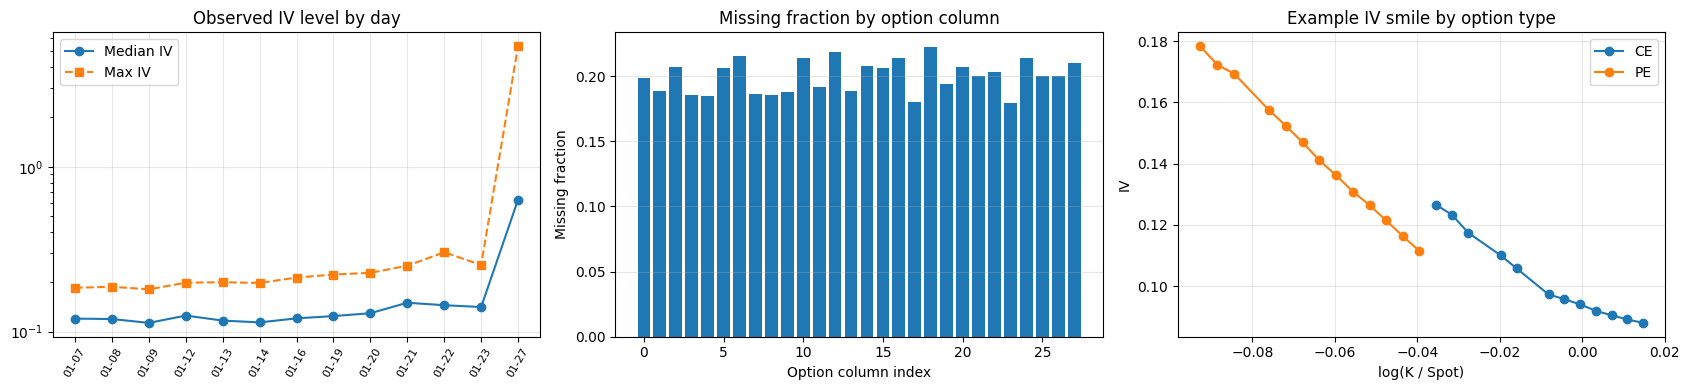

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Daily median/max IV
daily_median = []
daily_max = []
for d in unique_dates:
    vals = iv_matrix[dates == d]
    vals = vals[~np.isnan(vals)]
    daily_median.append(np.median(vals))
    daily_max.append(np.max(vals))

axes[0].plot(range(len(unique_dates)), daily_median, marker="o", label="Median IV")
axes[0].plot(range(len(unique_dates)), daily_max, marker="s", linestyle="--", label="Max IV")
axes[0].set_yscale("log")
axes[0].set_title("Observed IV level by day")
axes[0].set_xticks(range(len(unique_dates)))
axes[0].set_xticklabels([d[5:] for d in unique_dates], rotation=60, fontsize=8)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Missing percentage per option
axes[1].bar(range(len(option_cols)), missing_mask.mean(axis=0))
axes[1].set_title("Missing fraction by option column")
axes[1].set_xlabel("Option column index")
axes[1].set_ylabel("Missing fraction")
axes[1].grid(axis="y", alpha=0.3)

# One example smile
example_row = np.where(~missing_mask.all(axis=1))[0][0]
for idx, label in [(call_idx, "CE"), (put_idx, "PE")]:
    x = log_moneyness[example_row, idx]
    y = iv_matrix[example_row, idx]
    ok = ~np.isnan(y)
    axes[2].plot(x[ok], y[ok], marker="o", linestyle="-", label=label)

axes[2].set_title("Example IV smile by option type")
axes[2].set_xlabel("log(K / Spot)")
axes[2].set_ylabel("IV")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Modelling Approach

For each timestamp and option type, a separate smile is reconstructed across log-moneyness.

The model has two parts:

1. **Cross-sectional smile estimate**
   - Interior missing strikes are estimated using a local weighted quadratic fit.
   - Edge missing strikes use linear extrapolation to avoid unstable polynomial wings.
   - Calls and puts are fitted separately.

2. **Causal residual adjustment**
   - After the smile fit, residuals are tracked per option column using an exponentially weighted moving average.
   - The residual feature uses only previous timestamps, so it does not introduce look-ahead bias.

This creates a deterministic and reproducible filled IV surface.

In [6]:
def local_weighted_quadratic(x_obs, y_obs, x_query, neighbors=5):
    """Estimate IV at one log-moneyness point using nearby observed smile points."""
    nearest = np.argsort(np.abs(x_obs - x_query))[:neighbors]
    x_fit = x_obs[nearest]
    y_fit = y_obs[nearest]

    degree = min(2, len(np.unique(x_fit)) - 1)

    if degree < 1:
        return float(np.mean(y_fit))

    weights = 1.0 / (1.0 + ((x_fit - x_query) / 0.02) ** 2)
    coeff = np.polyfit(x_fit, y_fit, deg=degree, w=weights)

    return float(np.polyval(coeff, x_query))


def cross_sectional_smile_surface(matrix):
    """Fit one call smile and one put smile per timestamp."""
    fitted = np.full_like(matrix, np.nan, dtype=float)

    for row in range(n_rows):
        for group_idx in [call_idx, put_idx]:
            x_all = log_moneyness[row, group_idx]
            y_all = matrix[row, group_idx]
            observed = ~np.isnan(y_all)

            if observed.sum() < 2:
                continue

            # Sort observed smile points by log-moneyness.
            sort_order = np.argsort(x_all[observed])
            x_obs = x_all[observed][sort_order]
            y_obs = y_all[observed][sort_order]

            for pos, col_id in enumerate(group_idx):
                xq = x_all[pos]

                # Interior region: local quadratic if enough points, otherwise linear interpolation.
                if x_obs.min() <= xq <= x_obs.max():
                    if observed.sum() < 4:
                        fitted[row, col_id] = np.interp(xq, x_obs, y_obs)
                    else:
                        fitted[row, col_id] = local_weighted_quadratic(x_obs, y_obs, xq)

                # Wing region: linear extrapolation from the nearest two points.
                else:
                    if xq < x_obs.min():
                        x1, x2 = x_obs[0], x_obs[1]
                        y1, y2 = y_obs[0], y_obs[1]
                    else:
                        x1, x2 = x_obs[-1], x_obs[-2]
                        y1, y2 = y_obs[-1], y_obs[-2]

                    fitted[row, col_id] = y1 + ((y1 - y2) / (x1 - x2)) * (xq - x1)

    return np.clip(fitted, MIN_IV, None)


def past_only_ewma(matrix, half_life):
    """Column-wise EWMA where row t only uses information from rows before t."""
    alpha = 1 - 0.5 ** (1 / half_life)

    output = np.full_like(matrix, np.nan, dtype=float)
    state = np.full(matrix.shape[1], np.nan, dtype=float)

    for row in range(matrix.shape[0]):
        output[row] = state

        current = matrix[row]
        valid = ~np.isnan(current)

        updated = state.copy()
        updated[valid] = np.where(
            np.isnan(state[valid]),
            current[valid],
            (1 - alpha) * state[valid] + alpha * current[valid]
        )

        state = updated

    return output


RESIDUAL_HALFLIFE = 3
RESIDUAL_WEIGHT = 0.5


def predict_iv_surface(matrix):
    """Final IV prediction surface used for both validation and submission."""
    smile_pred = cross_sectional_smile_surface(matrix)

    residual = np.where(
        ~np.isnan(matrix),
        matrix - smile_pred,
        np.nan
    )

    residual_signal = past_only_ewma(residual, RESIDUAL_HALFLIFE)

    prediction = smile_pred + RESIDUAL_WEIGHT * np.where(
        np.isnan(residual_signal),
        0.0,
        residual_signal
    )

    return np.clip(prediction, MIN_IV, None)

## 6. Local Validation

Because Kaggle hides the true missing values, validation is done by masking known IV cells and checking whether the model can reconstruct them.

Two checks are used:

- **Random hold-out**: hides 20% of observed cells across the panel.
- **Forward hold-out**: hides cells in the later part of the timeline to confirm that the model is not relying on future data.

The score reported is Mean Squared Error (MSE).

In [7]:
def mse_split_by_regime(prediction, validation_mask):
    squared_error = (prediction - iv_matrix) ** 2
    expiry_cells = np.broadcast_to(is_expiry_day[:, None], iv_matrix.shape)

    mse_all = np.nanmean(squared_error[validation_mask])
    mse_non_expiry = np.nanmean(squared_error[validation_mask & ~expiry_cells])
    mse_expiry = np.nanmean(squared_error[validation_mask & expiry_cells])

    return mse_all, mse_non_expiry, mse_expiry


def make_validation_mask(seed, fraction=0.20, later_period_only=False):
    observed = ~np.isnan(iv_matrix)

    if later_period_only:
        cutoff = int(n_rows * 0.70)
        observed = observed & (np.arange(n_rows)[:, None] >= cutoff)

    candidates = np.argwhere(observed)
    rng = np.random.default_rng(seed)
    selected = rng.choice(
        len(candidates),
        size=int(fraction * len(candidates)),
        replace=False
    )

    mask = np.zeros_like(observed, dtype=bool)

    for row, col in candidates[selected]:
        mask[row, col] = True

    return mask


print("Random 20% hold-out validation")
print(f"{'Seed':>6} {'MSE_all':>12} {'MSE_non_expiry':>16} {'MSE_expiry':>14}")

random_scores = []

for seed in [7, 11, 23, 42, 99]:
    val_mask = make_validation_mask(seed, fraction=0.20)

    train_matrix = iv_matrix.copy()
    train_matrix[val_mask] = np.nan

    pred_matrix = predict_iv_surface(train_matrix)

    mse_all, mse_non_expiry, mse_expiry = mse_split_by_regime(pred_matrix, val_mask)
    random_scores.append(mse_all)

    print(f"{seed:>6} {mse_all:>12.3e} {mse_non_expiry:>16.3e} {mse_expiry:>14.3e}")

print(f"Mean random validation MSE: {np.mean(random_scores):.3e}")

# Forward hold-out
forward_mask = make_validation_mask(7, fraction=0.20, later_period_only=True)
forward_train = iv_matrix.copy()
forward_train[forward_mask] = np.nan
forward_prediction = predict_iv_surface(forward_train)

mse_all, mse_non_expiry, mse_expiry = mse_split_by_regime(forward_prediction, forward_mask)

print("\nForward hold-out validation")
print(f"MSE_all        : {mse_all:.3e}")
print(f"MSE_non_expiry : {mse_non_expiry:.3e}")
print(f"MSE_expiry     : {mse_expiry:.3e}")

Random 20% hold-out validation
  Seed      MSE_all   MSE_non_expiry     MSE_expiry
     7    4.739e-05        9.454e-06      5.405e-04
    11    5.749e-05        6.481e-06      6.523e-04
    23    4.324e-05        6.945e-06      4.485e-04
    42    1.257e-04        9.426e-06      1.491e-03
    99    6.906e-05        8.665e-06      7.646e-04
Mean random validation MSE: 6.858e-05

Forward hold-out validation
MSE_all        : 1.820e-04
MSE_non_expiry : 1.302e-05
MSE_expiry     : 6.921e-04


## 7. Fit Final Model on the Complete Dataset

The final prediction surface is generated using the same function used in validation. Observed IV values are preserved, and predictions are inserted only where the original dataset had missing values.

In [8]:
predicted_surface = predict_iv_surface(iv_matrix)

filled_df = raw_df.copy()

for col_idx, col_name in enumerate(option_cols):
    filled_df[col_name] = np.where(
        np.isnan(iv_matrix[:, col_idx]),
        predicted_surface[:, col_idx],
        iv_matrix[:, col_idx]
    )

assert filled_df[option_cols].isna().sum().sum() == 0, "There are still missing IV values."

filled_values = filled_df[option_cols].to_numpy(float)

print("Remaining missing values:", int(filled_df[option_cols].isna().sum().sum()))
print(f"Filled IV range: {filled_values.min():.4f} to {filled_values.max():.4f}")
print(f"Predicted missing-cell range: {predicted_surface[np.isnan(iv_matrix)].min():.4f} to {predicted_surface[np.isnan(iv_matrix)].max():.4f}")

filled_df.to_csv(FILLED_DATASET_PATH, index=False)
print("Saved:", FILLED_DATASET_PATH)

Remaining missing values: 0
Filled IV range: 0.0168 to 5.8007
Predicted missing-cell range: 0.0195 to 5.8007
Saved: /kaggle/working/filled_dataset.csv


## 8. Generate Kaggle Submission

The submission file contains only the cells that were originally missing. The required ID format is:

`datetime||option_column`

The output file is saved as `submission.csv`.

In [9]:
submission_rows = []

for col_name in option_cols:
    missing_rows = raw_df.index[raw_df[col_name].isna()]

    for row_idx in missing_rows:
        submission_rows.append({
            "id": f"{raw_df.loc[row_idx, 'datetime']}{ID_SEPARATOR}{col_name}",
            "value": filled_df.loc[row_idx, col_name]
        })

submission = pd.DataFrame(submission_rows, columns=["id", "value"])
submission = submission.sort_values("id").reset_index(drop=True)

submission.to_csv(SUBMISSION_PATH, index=False)

print("Saved:", SUBMISSION_PATH)
print("Submission shape:", submission.shape)
print("Expected rows:", int(np.isnan(iv_matrix).sum()))
print("Missing values in submission:")
print(submission.isna().sum())

submission.head()

Saved: /kaggle/working/submission.csv
Submission shape: (5460, 2)
Expected rows: 5460
Missing values in submission:
id       0
value    0
dtype: int64


,id,value
0,07-01-2026 09:15||NIFTY27JAN2624100PE,0.163427
1,07-01-2026 09:15||NIFTY27JAN2625500CE,0.113834
2,07-01-2026 09:15||NIFTY27JAN2625800CE,0.101030
3,07-01-2026 09:20||NIFTY27JAN2624000PE,0.170729
4,07-01-2026 09:20||NIFTY27JAN2624200PE,0.159598


## 9. Final Notes

This notebook is fully deterministic and should reproduce the same `submission.csv` on every run.

### Key assumptions

- IV varies smoothly across nearby strikes at the same timestamp.
- Calls and puts should be fitted separately because their smile structures differ.
- Same-timestamp cross-sectional data is allowed.
- Time-based residual information must be strictly past-only to avoid look-ahead bias.

### Summary

The final model combines a cross-sectional smile reconstruction with a causal residual correction. This keeps the solution financially interpretable, reproducible, and aligned with the structure of implied volatility surfaces.